In [1]:
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'  # For sharper figures, but it takes more time
import scipy as sp
from copy import deepcopy 

from lisatools.utils.constants import *
from lisatools.sensitivity  import AE1SensitivityMatrix
from bbhx.waveformbuild import BBHWaveformFD

# Immports for generating simulated LISA data
import noise_generation as noise_generation
from tools.LISASimulator import LISASimulator
from tools.likelihood import get_dh, get_hh
import tools.likelihood as likelihood
from tools.save_and_load_DE import load_de_results

# Imports for MCMC
from tools.time_freq_likelihood import TimeFreqLikelihood
from eryn.ensemble import EnsembleSampler
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.state import State
from tools.MBHB_differential_evolution import transform_bbhx_to_parameters

# Imports for plotting
from chainconsumer import Chain, ChainConsumer, make_sample, Truth
import pandas as pd
gpu = False
if gpu:
    import cupy as cp
else:
    import numpy as cp

No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU interpolation available.
No CuPy or GPU response available.


# Generating Simulated LISA Data

In [2]:
Tobs = 1.2*YRSID_SI/12
dt = 5.
include_T_channel = False

wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), use_gpu=gpu)
sim = LISASimulator(Tobs=Tobs, dt=dt, wave_gen=wave_gen, include_T_channel=include_T_channel)

m1 = 3e5
m2 = 1.5e5
a1 = 0.753
a2 = 0.621
dist = 10 * PC_SI * 1e9
phi_ref = 0.0 #np.pi/2
f_ref = 0.0
inc = 0.224
lam = 60*(np.pi/180)
beta = 20*(np.pi/180)
psi = 0
t_ref = Tobs - (24*60*60)
parameters = np.array([m1, m2, a1, a2, dist, phi_ref, f_ref, inc, lam, beta, psi, t_ref])
modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]
waveform_kwargs = dict(length=1024, direct=False, fill=True, squeeze=False, modes=modes)

data_t, data_f, f_array, t_array, sens_mat = sim(seed = 42, parameters=parameters, waveform_kwargs=waveform_kwargs)
waveform_kwargs.update(freqs=f_array)

print(sim.SNR_optimal()[0])

1865.763357919106


# Pre-Merger

In [3]:
hours_before_merger = 10
time_before_merger = hours_before_merger*60*60
cutoff_time = t_ref - time_before_merger
width_of_tref_prior = 20
max_time = t_ref + (width_of_tref_prior - hours_before_merger)*60*60
nperseg = 1414

(305,) (1041,)


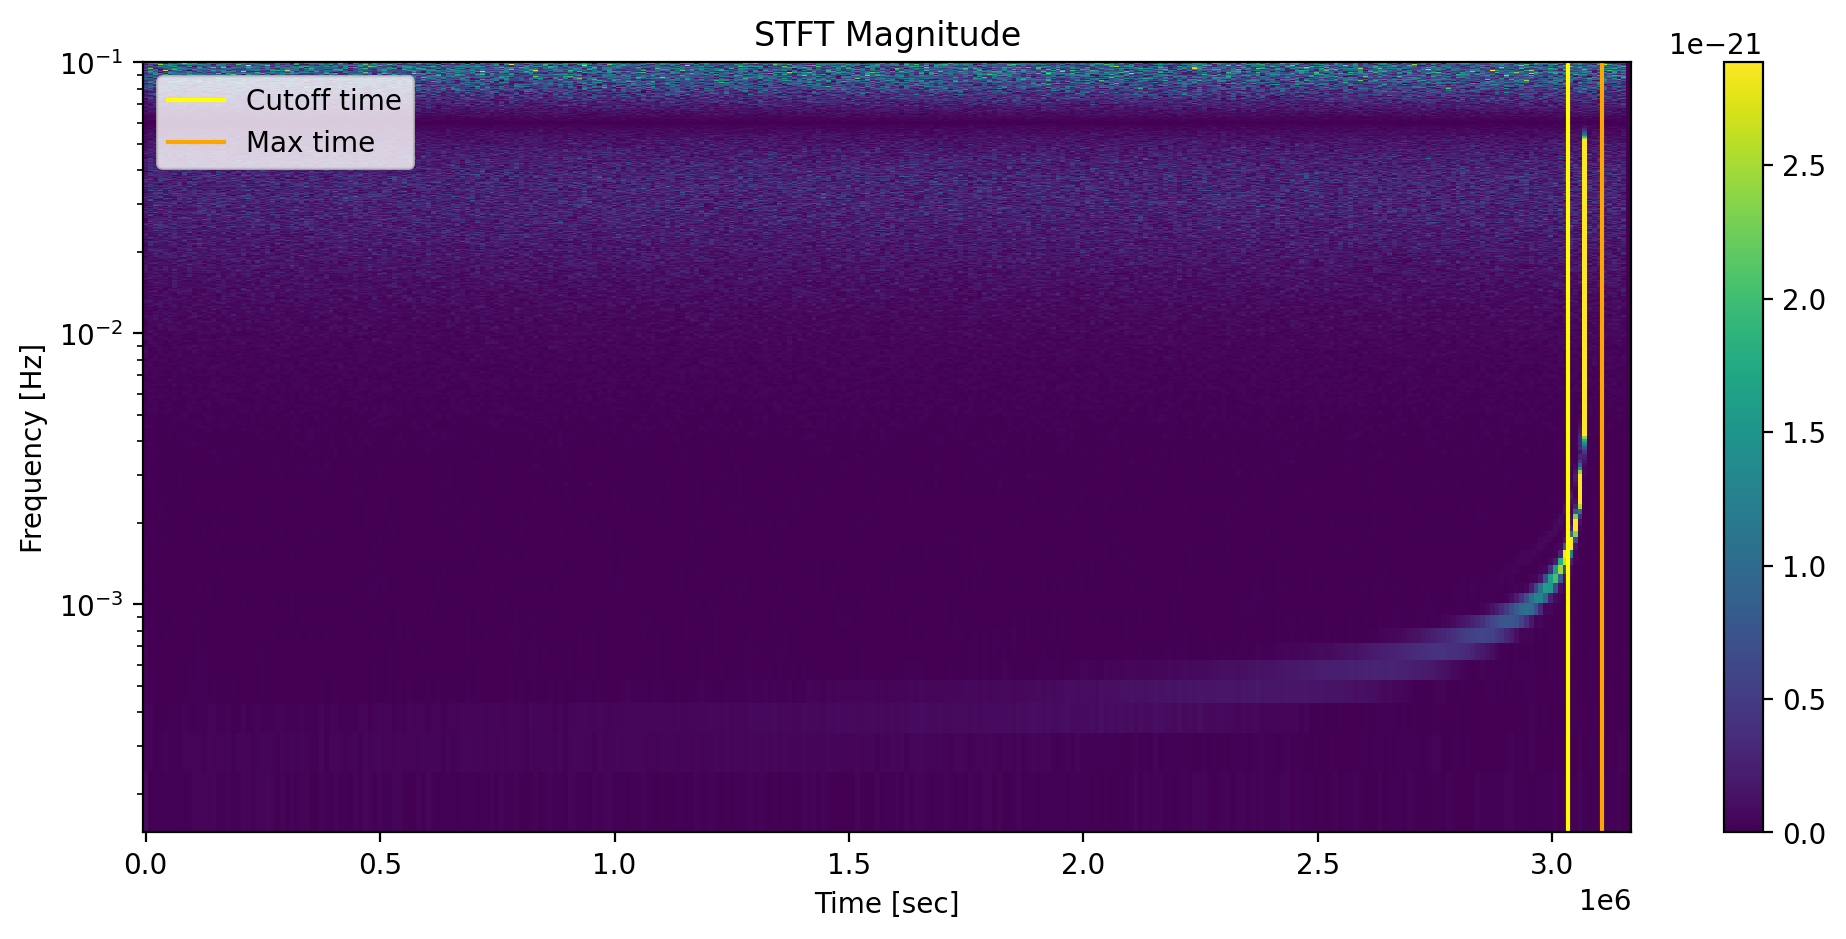

In [4]:
f, t, Zxx = sp.signal.stft(data_t[0], fs=1/sim.dt, nperseg=2081, noverlap=0)

print(t.shape, f.shape)

max_freq_idx = np.searchsorted(f, 0.1)
min_freq_idx = np.searchsorted(f, 1e-4)

plt.figure(figsize=(12, 5))
plt.pcolormesh(t, f[min_freq_idx:max_freq_idx], np.abs(Zxx[min_freq_idx:max_freq_idx]), vmin=0,
               vmax=np.max(np.abs(Zxx[min_freq_idx:max_freq_idx]))/10)
plt.yscale('log')
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.axvline(cutoff_time, color='yellow', label='Cutoff time')
plt.axvline(max_time, color='orange', label='Max time')
plt.legend(loc='upper left')
plt.colorbar()

In [5]:
analysis = TimeFreqLikelihood(data_t=data_t, wave_gen=wave_gen, nperseg=nperseg)
analysis.pre_merger(time_before_merger=time_before_merger, t_ref=t_ref, t_array=t_array)
analysis.get_stft_of_data()
print("Best likelihood (true parameters)= ", analysis.calculate_time_frequency_likelihood(*parameters, 
                                                waveform_kwargs=waveform_kwargs))

Best likelihood (true parameters)=  -492.1645973724095


# MCMC

In [6]:
# MCMC parameters
nwalkers = 24
ntemps = 4
ndims = 11
nleaves_max = 1
nsteps = 10
perturb_frac = 0.01

param_labels = [
    r"$M_T \, [\mathrm{M_\odot}]$",
    r"$q$",
    r"$a_1$",
    r"$a_2$",
    r"$d_L \, [\mathrm{Gpc}]$",
    r"$\phi_{\mathrm{ref}}$",
    r"$\cos(\iota)$",
    r"$\lambda$",
    r"$\sin(\beta)$",
    r"$\psi$",
    r"$t_{\mathrm{c}} \, [\mathrm{hrs}]$"
]

In [7]:
def likelihood(x, freqs, TimeFreqLikelihood_object):
    all_parameters = np.zeros(12)
    mT = x[0]
    q = x[1]
    all_parameters[0] = mT / (1 + q)
    all_parameters[1] = mT * q / (1 + q)
    all_parameters[2] = x[2]
    all_parameters[3] = x[3]
    all_parameters[4] = x[4] * PC_SI * 1e9
    all_parameters[5] = x[5]
    all_parameters[6] = f_ref
    all_parameters[7] = np.arccos(x[6])
    all_parameters[8] = x[7]
    all_parameters[9] = np.arcsin(x[8])
    all_parameters[10] = x[9]
    all_parameters[11] = x[10]

    ll = TimeFreqLikelihood_object.calculate_time_frequency_likelihood(
        *all_parameters,
        waveform_kwargs=dict(
        length=1024, 
        direct=False,
        fill=True,
        squeeze=False,
        freqs=freqs,
        modes=modes
        )
    )
    return ll

In [ ]:
priors = {"mbh": ProbDistContainer({
    0 : uniform_dist(1e5, 1e6),                  # mT = m1 + m2
    1 : uniform_dist(0.01, 0.99),            # q = m2/m1
    2 : uniform_dist(-1, +1),  # a1
    3 : uniform_dist(-1, +1),  # a2
    4 : uniform_dist(1, 50),                 # dist in Mpc
    5 : uniform_dist(0, 2*np.pi),            # phi_ref
    6 : uniform_dist(-1, 1),                     # cos(inc)
    7 : uniform_dist(0.0, 2 * np.pi),            # lam
    8 : uniform_dist(-1.0, 1.0),                 # sin(beta)
    9 : uniform_dist(0.0, np.pi),                # psi
    10: uniform_dist(cutoff_time, max_time),     # t_ref
})}

periodic = {"mbh": {5: 2 * np.pi,   # phi_ref
                    7: 2 * np.pi,   # lam
                    9: np.pi  }}    # psi

In [14]:
sampler = EnsembleSampler(
    nwalkers,
    ndims,
    likelihood,
    priors,
    args=(f_array, analysis),
    branch_names=["mbh"],
    tempering_kwargs=dict(ntemps = ntemps),
    nleaves_max=dict(mbh = nleaves_max),
    periodic=periodic
)

In [15]:
def DE_to_MCMC_params(x0, cutoff_time):
        mT, q, a1, a2, dist_Gpc, phi_ref, cos_inc, lam, sin_beta, psi, t_ref_01 = x0
        mT_exp = np.exp(mT)
        dist_Mpc = dist_Gpc 
        phi_ref = phi_ref % (2*np.pi)
        time_to_coalescence = t_ref_01 * (60*60*24) + cutoff_time
        return np.array([mT_exp, q, a1, a2, dist_Mpc, phi_ref, cos_inc, lam, sin_beta, psi, time_to_coalescence])

x0 = load_de_results(filepath='differential_evolution/differential_evolution_results/tf_run_20250902_183628.npz')
found_parameters_DE = DE_to_MCMC_params(x0['found_parameters'], cutoff_time=cutoff_time)
print("Normalized found Parameters by DE: ", x0['found_parameters'])
print("Parameters found by DE: ", found_parameters_DE)


Normalized found Parameters by DE:  [12.97308981  0.65360445  0.66373592  0.77892493  9.68672574  0.03885824
  0.93715349  1.04747089  0.33508785  0.4203114   0.41678529]
Parameters found by DE:  [4.30666724e+05 6.53604445e-01 6.63735921e-01 7.78924933e-01
 9.68672574e+00 3.88582438e-02 9.37153491e-01 1.04747089e+00
 3.35087847e-01 4.20311402e-01 3.06942523e+06]


In [20]:
from scipy.stats import truncnorm

injection_parameters = np.array([m1+m2, m2/m1, a1, a2, dist / (PC_SI * 1e9), phi_ref, np.cos(inc), lam, np.sin(beta), psi, t_ref])

from tools.MBHB_differential_evolution import transform_parameters_to_bbhx


starting_points = np.zeros(shape=[ntemps, nwalkers, nleaves_max, found_parameters_DE.shape[0]])

# Perturb the injection parameters to create starting points for the walkers
perturb_frac = 1e-3

non_periodic_params = [0, 1, 2, 3, 4, 6, 7, 8, 10]  # indices of non-periodic parameters

# For non-periodic parameters, draw from a truncated normal distribution around the injection parameters
for i in non_periodic_params:
    low, high = priors["mbh"].priors[i][1].min_val, priors["mbh"].priors[i][1].max_val
    mu = found_parameters_DE[i]
    sigma = perturb_frac * (high - low)
    a, b = (low - mu) / sigma, (high - mu) / sigma
    starting_points[:, :, :, i] = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=(ntemps, nwalkers, nleaves_max))

# For periodic parameters, draw from a normal distribution around the injection parameters and then wrap around the period
for i, period in periodic["mbh"].items():
    sigma = perturb_frac * period
    perturbed = found_parameters_DE[i] + sigma * np.random.randn(ntemps, nwalkers, nleaves_max)
    starting_points[:, :, :, i] = np.mod(perturbed, period)

starting_state = State({"mbh": starting_points})

Mean of parameter 10 is 3069414.97635456
Sigma of parameter 10 is 72.0


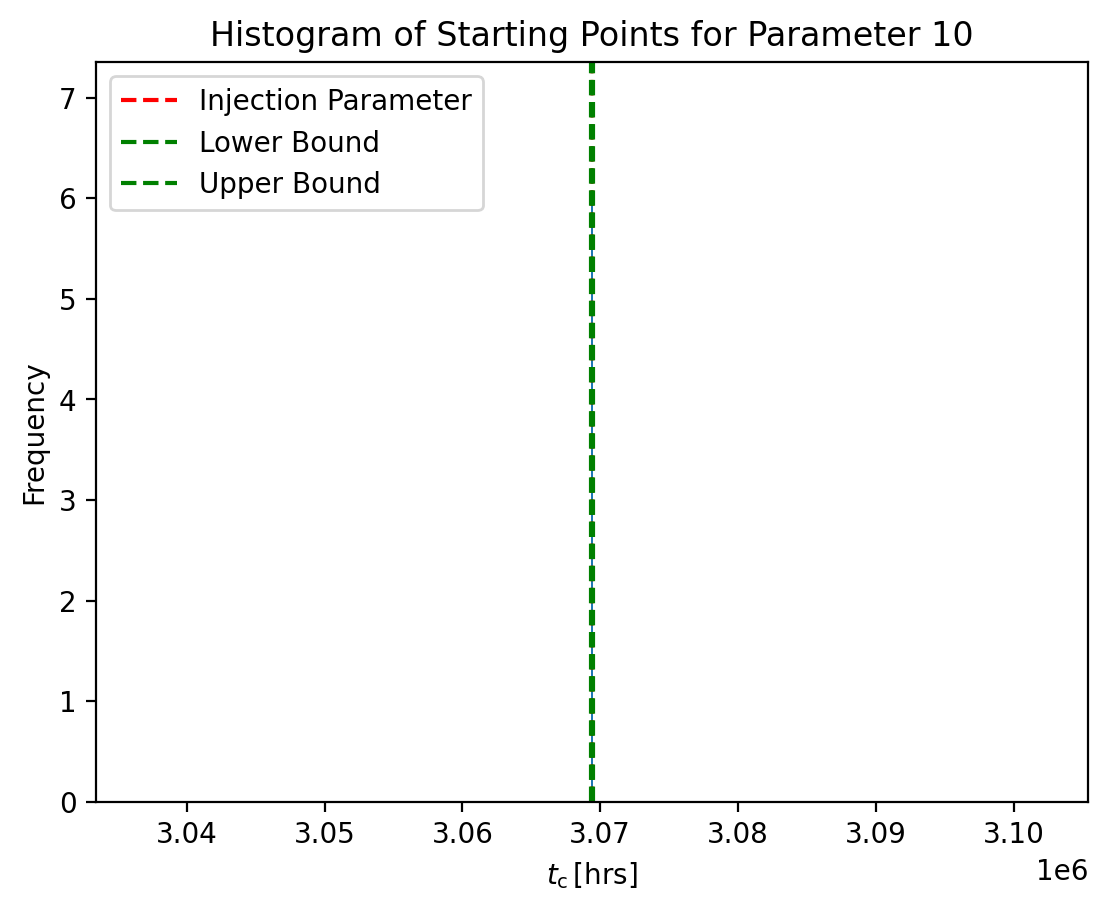

In [21]:
# Plot the histogram of the starting points
index_for_histogram = 10

size_of_prior = priors["mbh"].priors[index_for_histogram][1].max_val - priors["mbh"].priors[index_for_histogram][1].min_val
print("Mean of parameter", index_for_histogram, "is", injection_parameters[index_for_histogram])
print("Sigma of parameter", index_for_histogram, "is", perturb_frac * size_of_prior)

plt.hist(starting_points[:, :, :, index_for_histogram].flatten(), bins=50)
plt.axvline(injection_parameters[index_for_histogram], color='r', linestyle='--', label='Injection Parameter')
plt.axvline(injection_parameters[index_for_histogram] - perturb_frac * size_of_prior, color='g', linestyle='--', label='Lower Bound')
plt.axvline(injection_parameters[index_for_histogram] + perturb_frac * size_of_prior, color='g', linestyle='--', label='Upper Bound')
plt.title(f'Histogram of Starting Points for Parameter {index_for_histogram}')
plt.xlabel(param_labels[index_for_histogram])
plt.xlim(priors["mbh"].priors[index_for_histogram][1].min_val, priors["mbh"].priors[index_for_histogram][1].max_val)
plt.ylabel('Frequency')
plt.legend(loc='upper left')
plt.show()

In [22]:
sampler.run_mcmc(starting_state, nsteps=10, progress=True)

100%|██████████| 10/10 [06:09<00:00, 36.98s/it]


Parameter $M_T \, [\mathrm{M_\odot}]$ in chain MCMC Results is not constrained
Parameter $a_2$ in chain MCMC Results is not constrained
Parameter $\lambda$ in chain MCMC Results is not constrained
Parameter $\psi$ in chain MCMC Results is not constrained
Parameter $t_{\mathrm{c}} \, [\mathrm{hrs}]$ in chain MCMC Results is not constrained


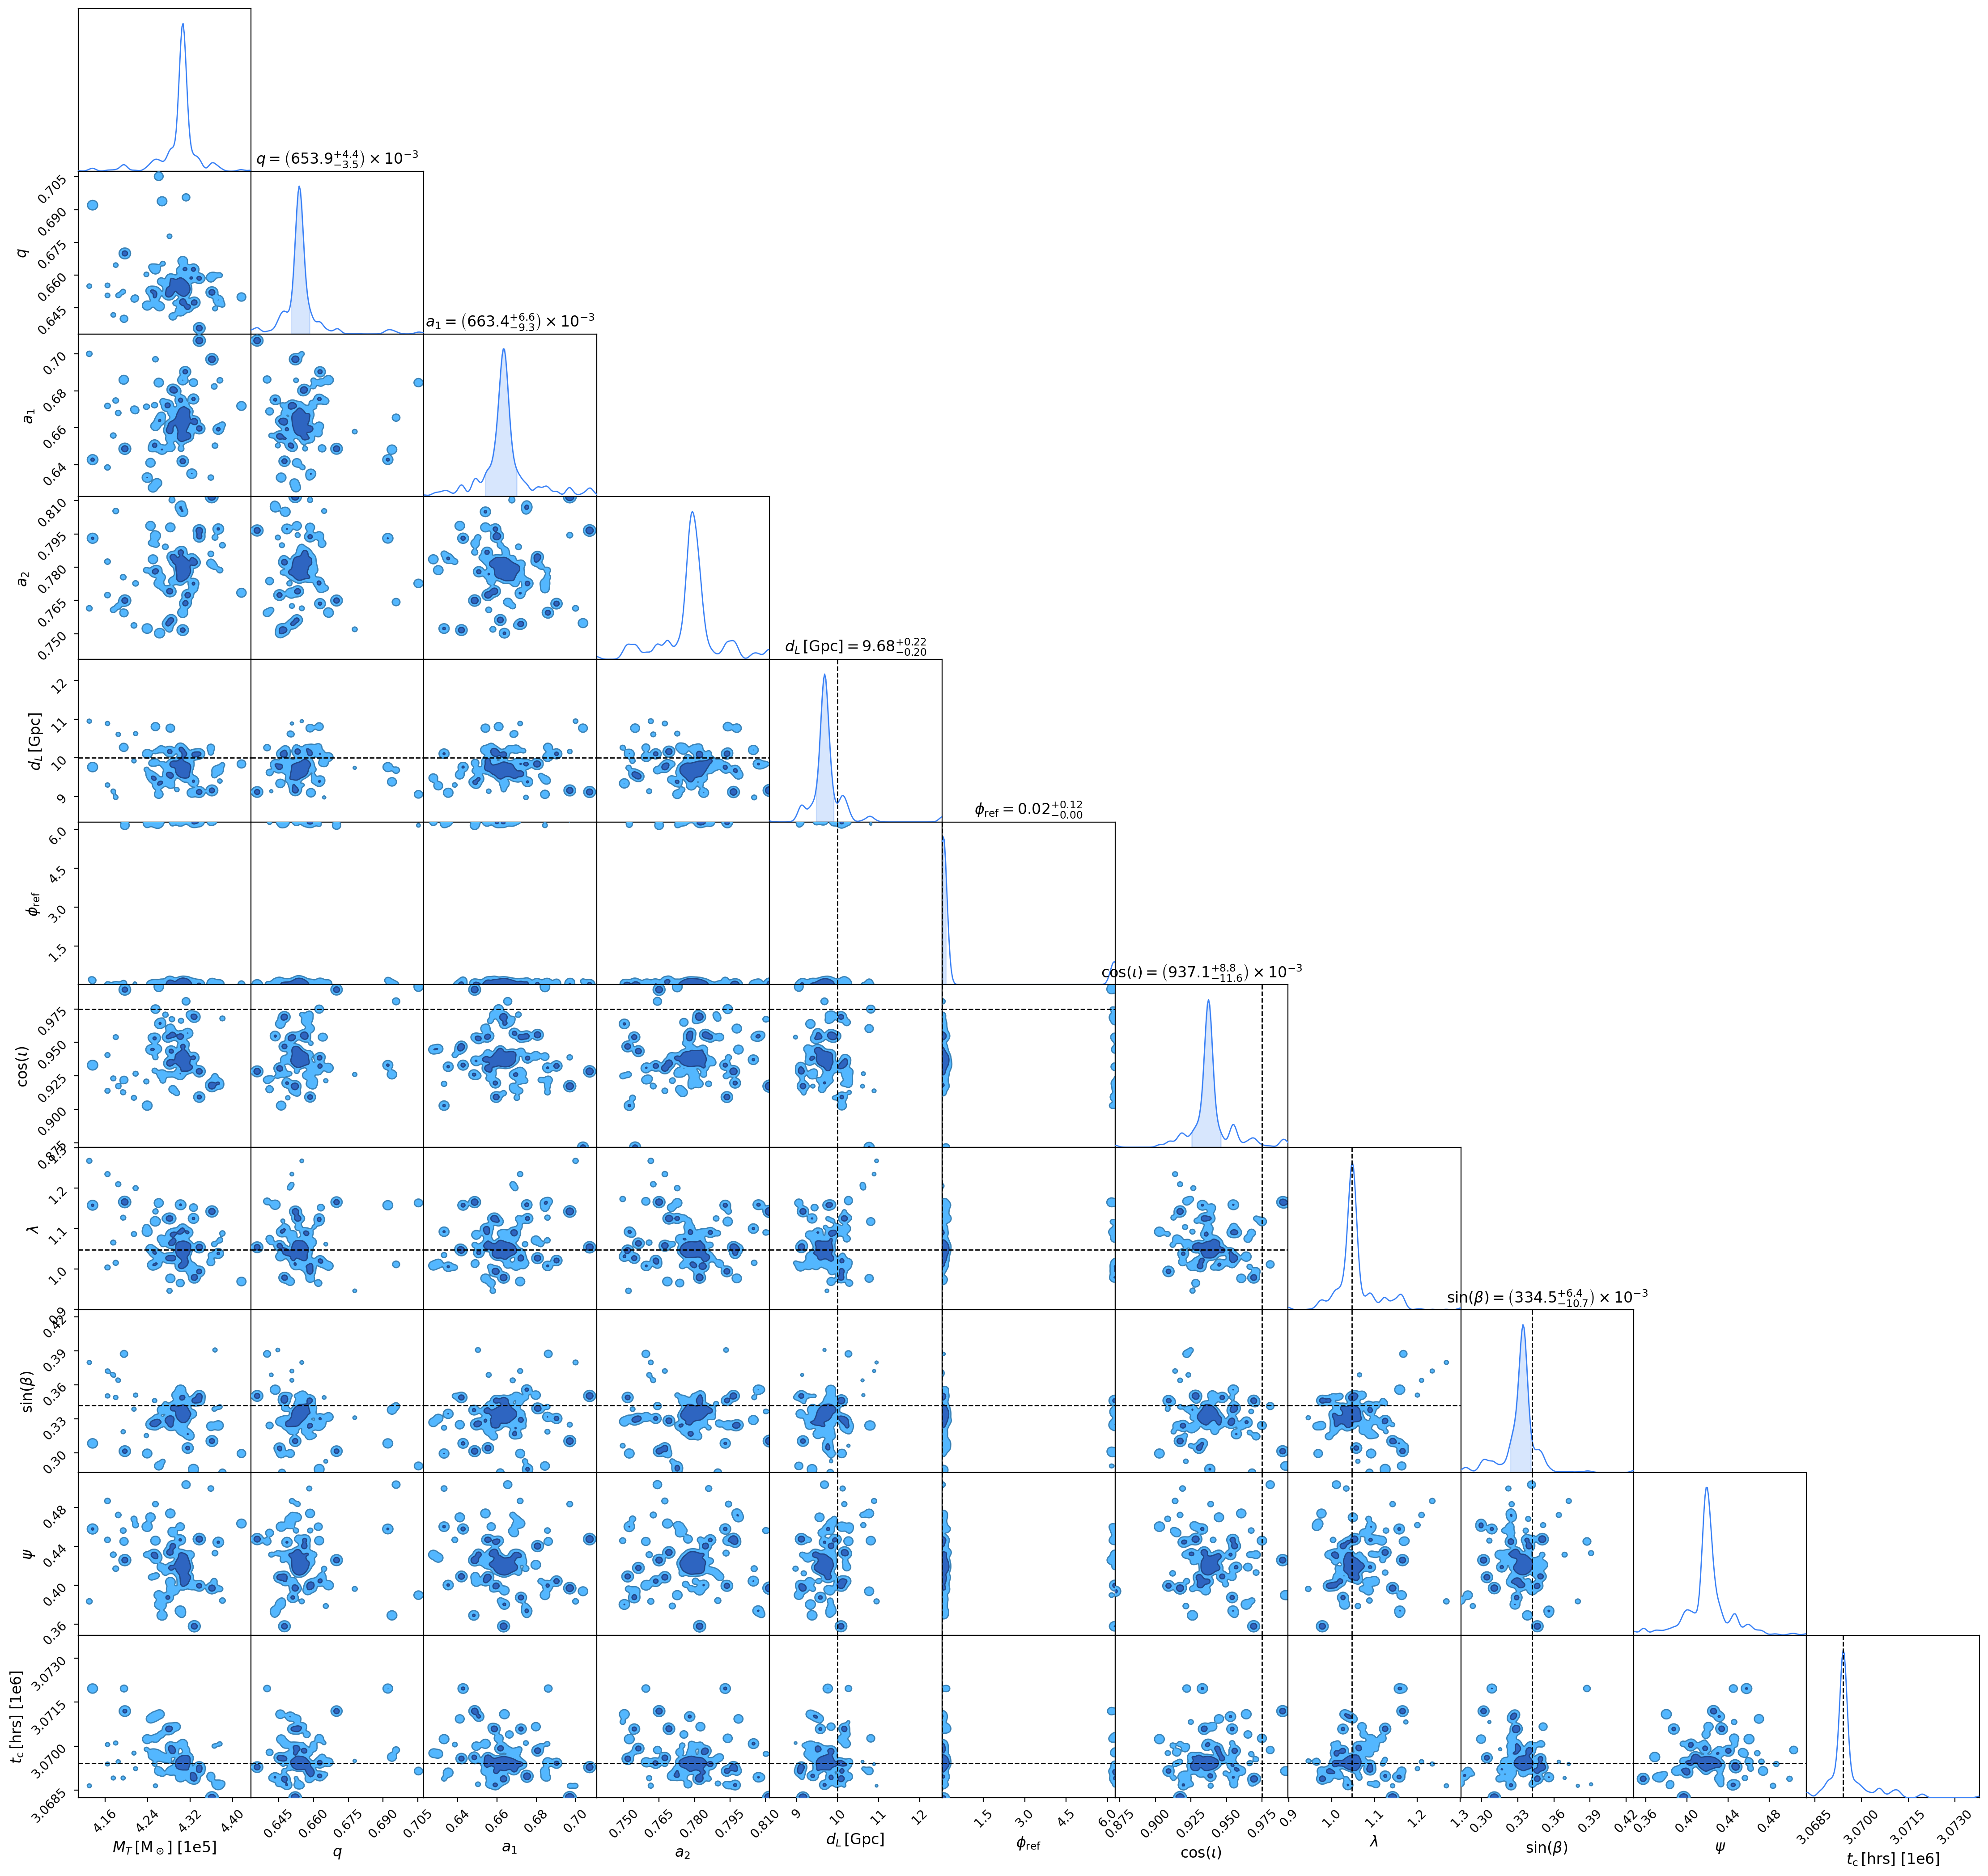

In [23]:
mcmc_results = sampler.get_chain()["mbh"]

samples = mcmc_results[:, 0].reshape(-1, 11)
df = pd.DataFrame(samples, columns=param_labels)

#df.drop(columns=[r"$f_{\mathrm{ref}}$"], inplace=True)  # Remove f_ref column if not needed
# df.to_pickle("mcmc_samples.pkl")

#burn_in_2 = 5000                           # Remove burn-in samples if needed
#df_post_burnin = df.iloc[burn_in_2:]

c = ChainConsumer() 
c.add_chain(Chain(samples=df, name="MCMC Results"))
c.add_truth(Truth(location = dict(zip(param_labels[:11], injection_parameters[:11]))))
fig_corner_plot = c.plotter.plot()
#fig_corner_plot.savefig("mcmc_results/mcmc_corner_plot.png", dpi=300)

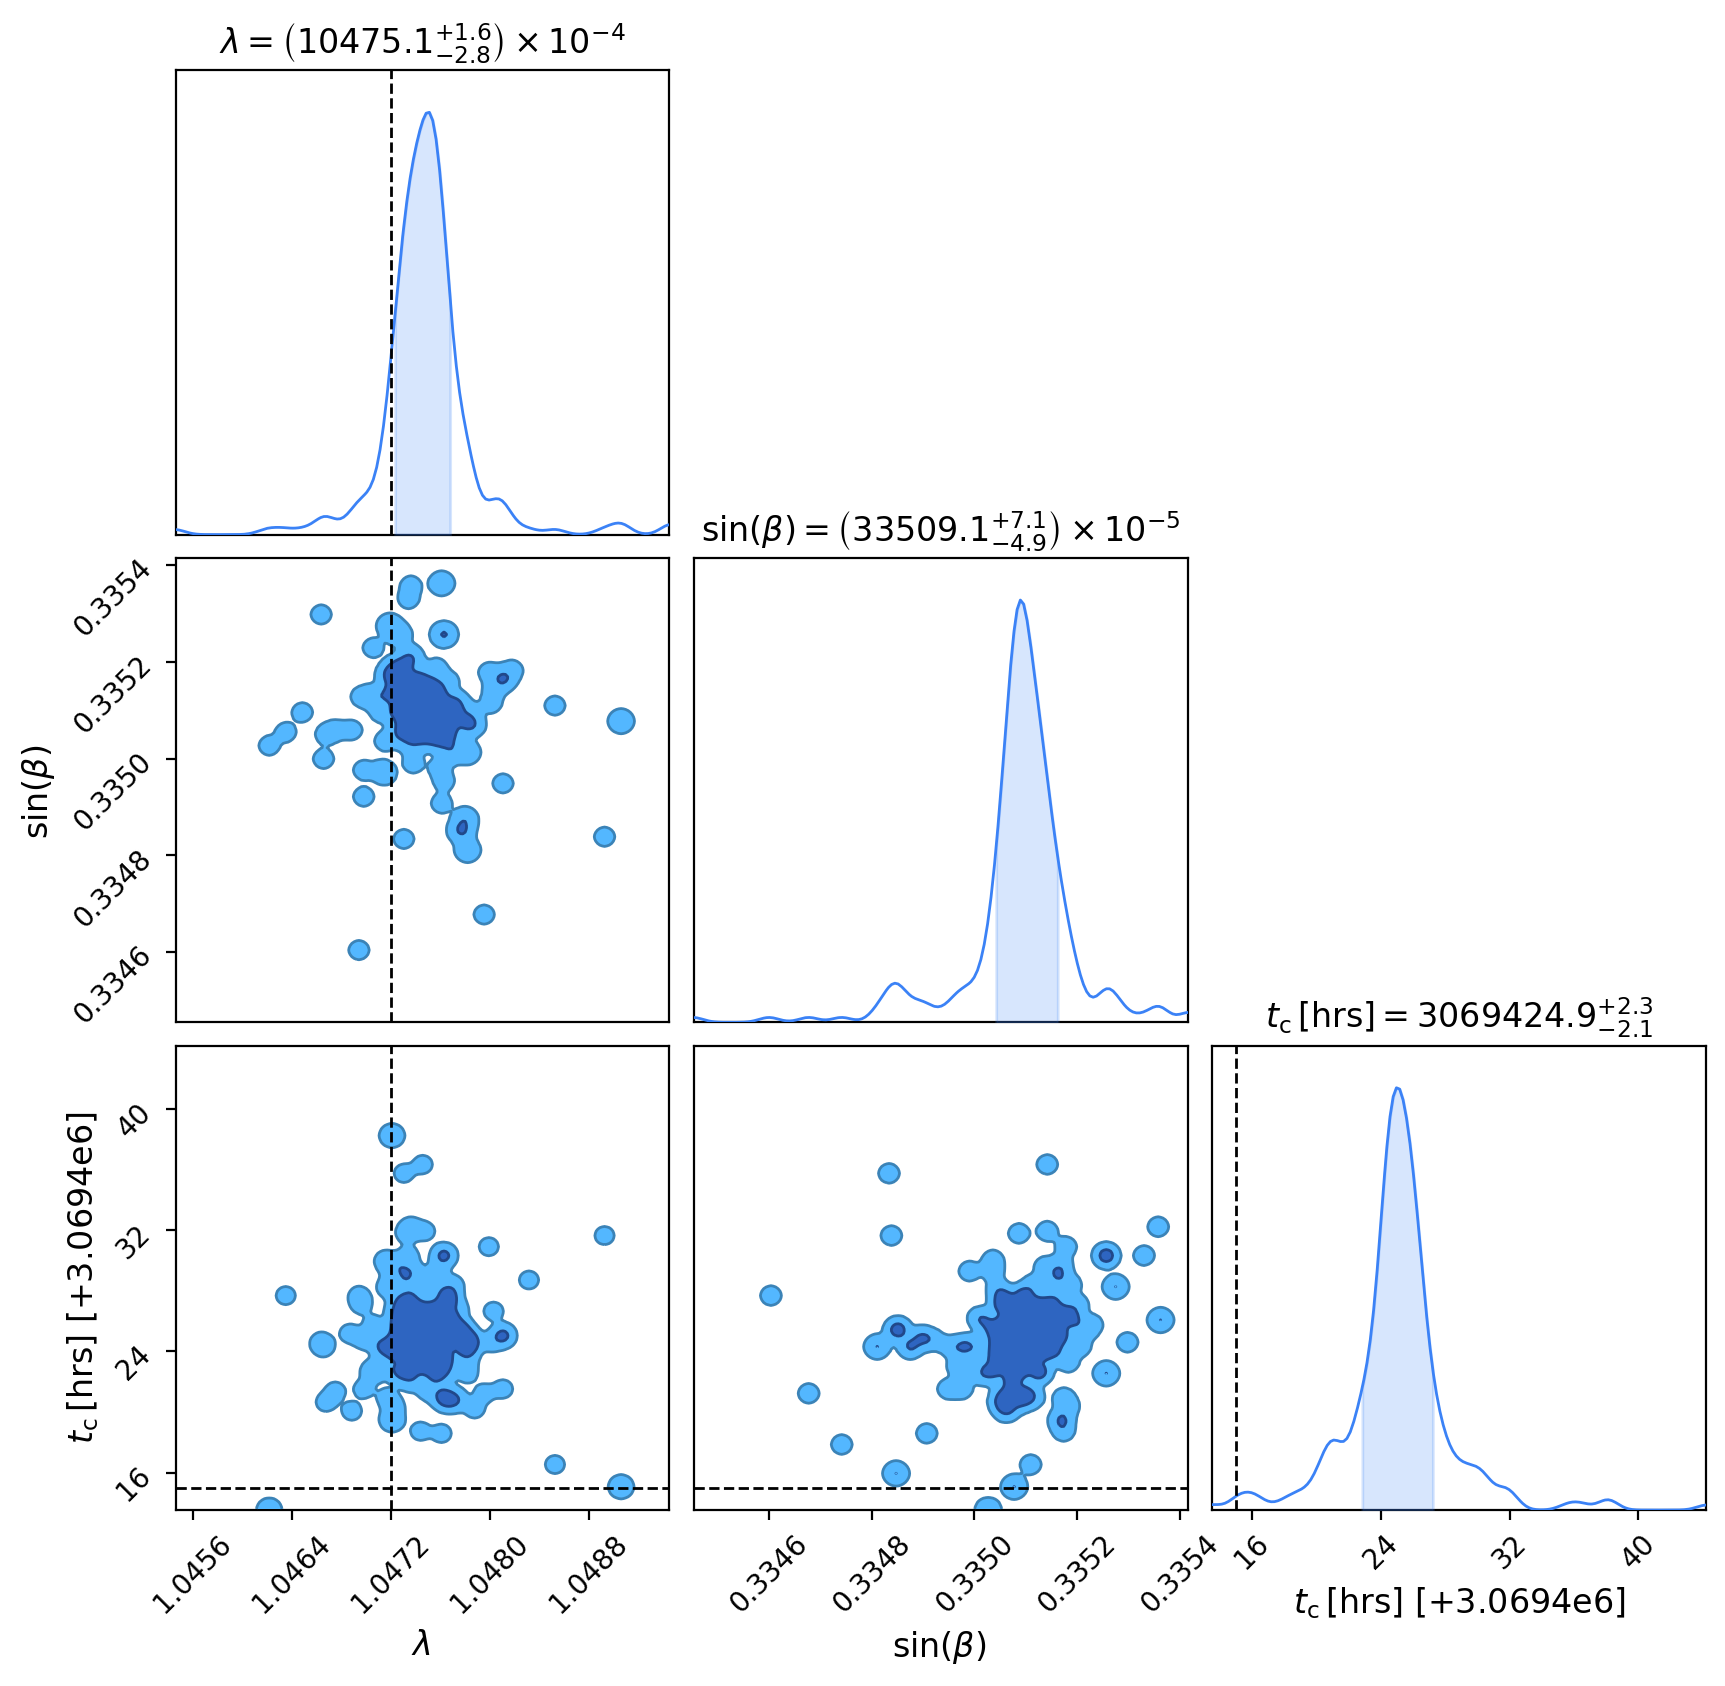

In [35]:
new_df = df[[param_labels[7], param_labels[8], param_labels[10]]]
new_injection_parameters = injection_parameters[[7, 8, 10]]

new_c = ChainConsumer() 
new_c.add_chain(Chain(samples=new_df, name="MCMC Results"))
new_c.add_truth(Truth(location={param_labels[7]: new_injection_parameters[0],
                                param_labels[8]: new_injection_parameters[1],
                                param_labels[10]: new_injection_parameters[2]}))
fig_corner_plot_lam_beta_tc = new_c.plotter.plot()
#fig_corner_plot_lam_beta_tc.savefig("mcmc_results/mcmc_corner_plot_lam_beta_tc.png", dpi=300)

In [ ]:
# Uncomment the following to save or load the chain

#sampler.get_chain()["mbh"]
#np.save("chain.npy", sampler.get_chain()["mbh"])
#arr = np.load("chain.npy")

In [ ]:
import matplotlib.cm as cm
plotting_walkers_range = nwalkers
colors = cm.viridis(np.linspace(0, 1, plotting_walkers_range))

fig_walkers, ax_walkers = plt.subplots(ndims, 1, sharex=True, figsize=(10, 2.5 * ndims))
fig_walkers.subplots_adjust(hspace=0.3)


for i in range(ndims):
    ax_walkers[i].axhline(injection_parameters[i], color='red', linestyle='--', linewidth=1.2, label="True value")
    for walk in range(plotting_walkers_range):
        ax_walkers[i].plot(mcmc_results[:, 0, walk, :, i].flatten(), color=colors[walk], alpha=0.6, linewidth=0.8)
    #ax[i].axhline(starting_points[0, walk, :, i], color='blue', linestyle='--', linewidth=1.2, label="Starting point of the last walker")

    ax_walkers[i].set_ylabel(param_labels[i], fontsize=12)
    #ax[i].legend(loc='upper right', fontsize=10)

ax_walkers[-1].set_xlabel("Number of steps", fontsize=12)

for axis in ax_walkers:
    axis.set_xlim(0, nsteps-1)

In [ ]:
log_like_samples = sampler.get_log_like() 

fig_log_like, ax_log_like = plt.subplots(figsize=(10, 6))
for i in range(nwalkers):
    ax_log_like.plot(np.arange(0, log_like_samples.shape[0]), log_like_samples[:,0,i], label=f"Walker {i+1}", color=colors[i], alpha=0.6, linewidth=0.8)

ax_log_like.axhline(analysis.calculate_time_frequency_likelihood(*parameters, waveform_kwargs=waveform_kwargs)  , 
            color='red', linestyle='--', linewidth=1.2, label="Likelihood of Injection Parameters")

ax_log_like.set_title("Log-likelihood samples")
ax_log_like.set_xlabel("Number of steps")
ax_log_like.set_ylabel("Log-likelihood")
ax_log_like.set_xlim(0, nsteps-1)

#plt.xticks(np.arange(1, nsteps+1))
#plt.ylim(-1000, 0)
#plt.legend()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# --- 0) Pull your samples
lam0 = new_df["$\\lambda$"].to_numpy()          # radians, expected in [0, 2π)
s0   = new_df["$\\sin(\\beta)$"].to_numpy()       # in [-1, 1]

# --- 1) Wrap λ to [-π, π] for Mollweide, keep s as-is
lam_array = (lam0 + np.pi) % (2*np.pi) - np.pi    # [-π, π]
s   = np.clip(s0, -1.0, 1.0)

# --- 2) Tile in longitude to handle periodicity near wrap
lam_tiled = np.concatenate([lam_array - 2*np.pi, lam_array, lam_array + 2*np.pi])
s_tiled   = np.concatenate([s, s, s])

# --- 3) KDE in (λ, s).  (Using Scott's rule; you can tweak with bw_method=...)
kde = gaussian_kde(np.vstack([lam_tiled, s_tiled]))

# Grid for evaluation
n_lam, n_s = 360, 181
lam_grid = np.linspace(-np.pi, np.pi, n_lam)
s_grid   = np.linspace(-1.0, 1.0, n_s)
LAM, S = np.meshgrid(lam_grid, s_grid, indexing="xy")

pdf = kde(np.vstack([LAM.ravel(), S.ravel()])).reshape(LAM.shape)

# Normalize the PDF over the rectangular grid in (λ, s)
# (each cell has equal area element dλ ds)
dlam = lam_grid[1] - lam_grid[0]
ds   = s_grid[1]   - s_grid[0]
pdf /= (pdf.sum() * dlam * ds)

# --- 4) Compute HPD thresholds for 50% and 90% credible regions
flat = pdf.ravel()
order = np.argsort(flat)[::-1]                 # highest first
cdf = np.cumsum(flat[order]) * dlam * ds       # cumulative probability

def hpd_level(prob):
    # returns the PDF threshold such that the HPD region encloses 'prob'
    idx = np.searchsorted(cdf, prob)
    return flat[order[idx]]

level50 = hpd_level(0.50)
level90 = hpd_level(0.90)

# Matplotlib expects increasing contour levels
levels_lines = np.sort([level50, level90])

# --- 5) Plot on Mollweide: convert s to β for the y-axis of the projection
BET = np.arcsin(np.clip(S, -1.0, 1.0))   # β in [-π/2, π/2]

fig = plt.figure(figsize=(10, 6))
ax = plt.subplot(111, projection="mollweide")

# Filled density background
# (We draw many fine levels so it looks smooth)
cf = ax.contourf(LAM, BET, pdf, levels=40)
cb = plt.colorbar(cf, orientation="horizontal", pad=0.07)
cb.set_label("Posterior density over dλ·d(sinβ)")

# HPD contour lines: 50% (inner) and 90% (outer)
cs = ax.contour(LAM, BET, pdf, levels=levels_lines, colors=["white", "red"], linewidths=1.5)
# Optional labels:
fmt = {levels_lines[0]: "50%", levels_lines[1]: "90%"}
ax.clabel(cs, inline=True, fmt=fmt, fontsize=9)

# Cosmetic bits
ax.set_xlabel("Ecliptic Longitude λ (rad)")
ax.set_ylabel("Ecliptic Latitude β (rad)")
ax.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import os
os.system("say 'Computation is done!'")